In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# 구글 드라이브 내의 정확한 경로로 수정합니다.
# 사용자가 입력한 'Colab Notebooks/charm_controllog/data' 앞에 마운트 경로를 추가합니다.
data_folder_path = '/content/drive/MyDrive/Colab Notebooks/charm_controllog/data'

print(f"탐색 중인 폴더 경로: {data_folder_path}")

if os.path.isdir(data_folder_path):
    # 해당 경로의 파일 목록을 가져와 갯수를 셉니다.
    files = [f for f in os.listdir(data_folder_path) if os.path.isfile(os.path.join(data_folder_path, f))]
    file_count = len(files)
    print(f"'data' 폴더를 찾았습니다. 파일 갯수: {file_count}개")
else:
    print(f"폴더를 찾을 수 없습니다: {data_folder_path}")
    print("드라이브 내의 실제 폴더 경로와 대소문자가 일치하는지 다시 한 번 확인해 주세요.")

탐색 중인 폴더 경로: /content/drive/MyDrive/Colab Notebooks/charm_controllog/data
'data' 폴더를 찾았습니다. 파일 갯수: 26개


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import os

csv_files = [f for f in os.listdir(data_folder_path) if f.endswith('.csv')]
df_list = []

for file in csv_files:
    file_path = os.path.join(data_folder_path, file)
    temp_df = pd.read_csv(file_path)
    df_list.append(temp_df)

if df_list:
    df = pd.concat(df_list, ignore_index=True)
    print(f"{len(df_list)}개의 파일을 학습용 데이터로 가져왔습니다. 가져온 파일로 추가한 df의 갯수는 {len(df)}개입니다.")
else:
    print("CSV 파일을 읽을 수 없습니다.")

25개의 파일을 학습용 데이터로 가져왔습니다. 가져온 파일로 추가한 df의 갯수는 7479개입니다.


In [ ]:
# 1. 레이블 인코딩
df['ControlScheme'] = df['ControlScheme'].map({'Keyboard&Mouse': 0, 'Gamepad': 1})

# 2. 데이터 균형 맞추기 (1:1 비율)
df_km_full = df[df['ControlScheme'] == 0]
df_gp_full = df[df['ControlScheme'] == 1]

min_len = min(len(df_km_full), len(df_gp_full))
print(f"데이터 균형화 이후 각 데이터 갯수: {min_len}")
df_km_balanced = resample(df_km_full, replace=False, n_samples=min_len, random_state=42)
df_gp_balanced = resample(df_gp_full, replace=False, n_samples=min_len, random_state=42)

df_balanced = pd.concat([df_km_balanced, df_gp_balanced]).sort_values(by=['ControlScheme', 'Time'])

# 3. 윈도우 세트 생성 (60행 단위)
def create_sequences(data, window_size=60):
    sequences = []
    labels = []
    # 각 컨트롤러별로 데이터를 나누어 시퀀스 생성 (데이터 혼선 방지)
    for scheme in [0, 1]:
        temp_df = data[data['ControlScheme'] == scheme].iloc[:, 2:] # Time, Scheme 제외한 MoveX, Y, AimX, Y
        for i in range(0, len(temp_df) - window_size, window_size):
            sequences.append(temp_df.iloc[i:i+window_size].values)
            labels.append(scheme)
    return np.array(sequences), np.array(labels)

X_raw, y = create_sequences(df_balanced)

데이터 균형화 이후 각 데이터 갯수: 3263


In [ ]:
def extract_features(sequences):
    extracted = []
    for seq in sequences:
        # seq 구조: [60, 4] -> MoveX, MoveY, AimX, AimY
        move_x, move_y = seq[:, 0], seq[:, 1]
        aim_x, aim_y = seq[:, 2], seq[:, 3]

        # 특징 1: Move Digital 여부 (소수점이 있으면 1, 정수(-1, 0, 1)만 있으면 0)
        is_analog = 1.0 if np.any(np.mod(move_x, 1) != 0) or np.any(np.mod(move_y, 1) != 0) else 0.0

        # 특징 2: Aim 분산 (Variance)
        aim_var = np.var(aim_x) + np.var(aim_y)

        # 특징 3: Aim 최대 속도 (Magnitude)
        aim_mag = np.max(np.sqrt(aim_x**2 + aim_y**2))

        # 특징 4: Zero Crossing Rate (조작 멈춤/움직임 빈도)
        zcr = np.mean(np.diff(np.sign(aim_x + aim_y)) != 0)

        # 원본 데이터와 특징 결합 (여기서는 예시로 시퀀스마다 하나의 특징 벡터 생성)
        # 만약 LSTM 입력으로 쓰고 싶다면 각 타임스텝에 이 특징들을 붙여줄 수 있습니다.
        feature_vec = [is_analog, aim_var, aim_mag, zcr]
        extracted.append(feature_vec)

    return np.array(extracted)

X_features = extract_features(X_raw)

In [ ]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

# 모델 설계
model = models.Sequential([
    layers.Input(shape=(60, 4)), # 60 steps, 4 features (MoveX, Y, AimX, Y)
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dense(16, kernel_regularizer=tf.keras.regularizers.l2(0.01), activation='relu'),
    layers.Dense(1, activation='sigmoid') # 이진 분류 (0: K&M, 1: Pad)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 학습
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

# 평가
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"테스트 정확도: {test_acc:.4f}")

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 303ms/step - accuracy: 0.4935 - loss: 0.8937 - val_accuracy: 0.3333 - val_loss: 0.8923
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5325 - loss: 0.8804 - val_accuracy: 0.3333 - val_loss: 0.8858
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.5325 - loss: 0.8688 - val_accuracy: 0.3333 - val_loss: 0.8791
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5325 - loss: 0.8546 - val_accuracy: 0.5556 - val_loss: 0.8698
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.6623 - loss: 0.8364 - val_accuracy: 0.5556 - val_loss: 0.8597
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.6623 - loss: 0.8149 - val_accuracy: 0.7778 - val_loss: 0.8452
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.7922 - loss: 0.7761 - val_accuracy: 0.7778 - val_loss: 0.8198
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8182 - loss: 0.7118 - val_accuracy: 1.0000 - val_loss: 0.766

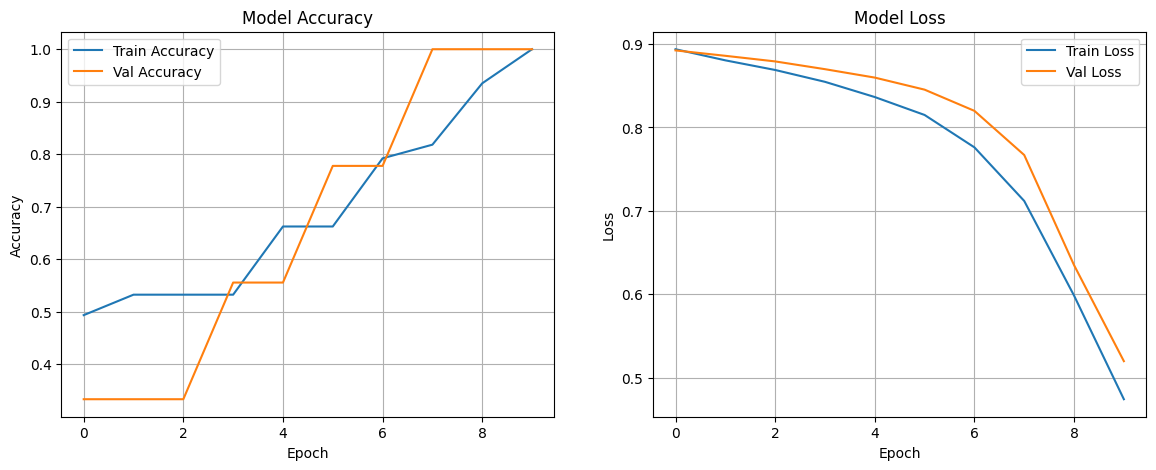

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with two subplots: Accuracy and Loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Plot Loss
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.show()

In [ ]:
pip install tf2onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 78.7 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import os

# 1. 모델을 SavedModel 형식으로 내보내기
temp_model_path = "temp_saved_model"
model.export(temp_model_path)

# 2. 터미널 명령어를 사용하여 SavedModel을 ONNX로 변환
# tf2onnx.convert.from_saved_model 대신 CLI 도구를 사용하는 것이 가장 확실합니다.
output_path = "model.onnx"

!python -m tf2onnx.convert --saved-model {temp_model_path} --output {output_path} --opset 13

if os.path.exists(output_path):
    print(f"\n성공: 모델이 {output_path}로 내보내졌습니다.")
else:
    print("\n오류: ONNX 파일 생성에 실패했습니다.")

Saved artifact at 'temp_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 60, 4), dtype=tf.float32, name='keras_tensor_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136905662265104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136905662263376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136905662266448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136905662263184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136905662266640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136905662264912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136905662266832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136905662260304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136905662266256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136905662267216: TensorSpec(shape=(), dtype=tf.resource, name=None)
2026-05-27 03:55:50.